In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

In [8]:
import sys
import os

# Add the project root to Python's search path and import the trained module
sys.path.append(os.path.abspath('..'))

import src.train as train_module

# Use the test results produced when `src.train` was imported
# (train_module.test_results contains the pipeline and test split)
pipe = train_module.test_results['Pipeline']
x_test = train_module.test_results['X_test']
y_test = train_module.test_results['Y_test']

y_pred = pipe.predict(x_test)
y_prob = pipe.predict_proba(x_test)[:, 1]  # probability for survival

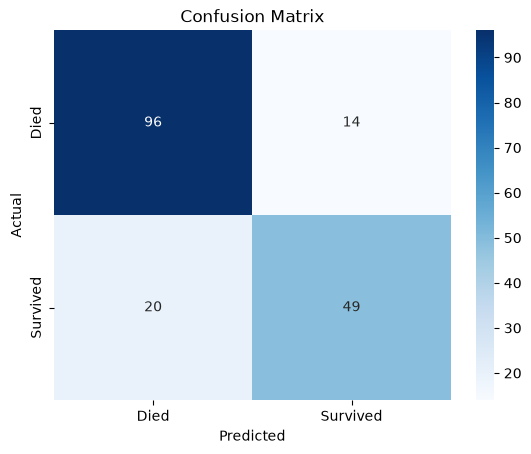

In [11]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/Users/bharathkbk.12/ai-ml-journey/week03-first-ml-model/data/confusion_matrix.png', dpi=150)
plt.show()

In [13]:
# 2. Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Died', 'Survived'])}")

Accuracy: 0.810
Precision: 0.778
Recall: 0.710
F1 Score: 0.742

              precision    recall  f1-score   support

        Died       0.83      0.87      0.85       110
    Survived       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



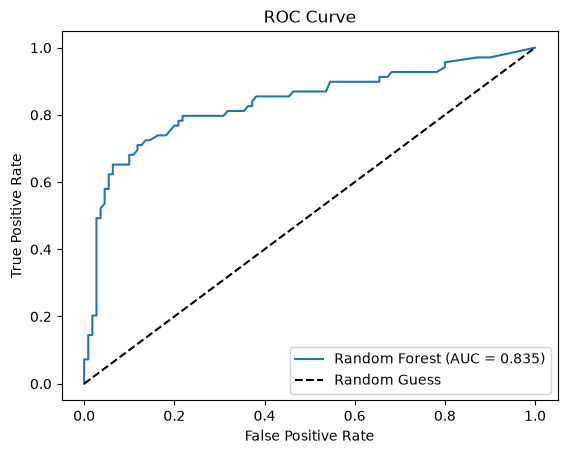

In [ ]:
# 3. Metrics
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.Figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('/Users/bharathkbk.12/ai-ml-journey/week03-first-ml-model/data/roc_curve.png', dpi=150)
plt.show()

In [14]:
# 4. Feature Importance
importances = pipe.named_steps['model'].feature_importances_
x = sns.load_dataset('titanic')
feat_names = x.columns
indices = np.argsort(importances) [::-1]



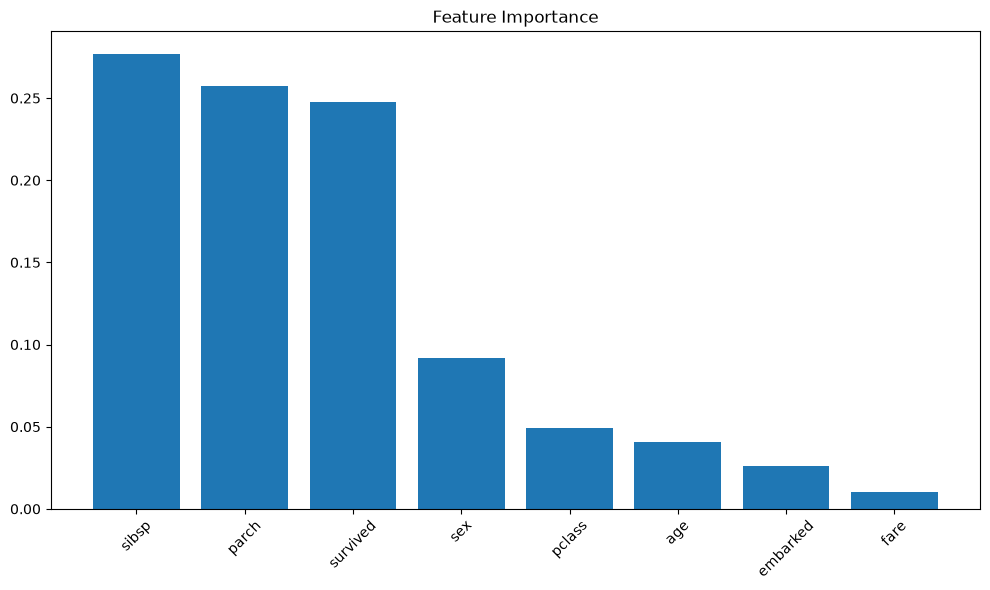

In [15]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), [feat_names[i] for i in indices], rotation=45)
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('/Users/bharathkbk.12/ai-ml-journey/week03-first-ml-model/data/feature_importance.png', dpi=150)
plt.show()